In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


In [10]:
# Define directories for training and testing images
# train_dir = '/Users/code/alzheimerDetect/AugmentedAlzheimerDataset'
# test_dir = '/Users/code/alzheimerDetect/OriginalDataset'

import os
import shutil
from sklearn.model_selection import train_test_split

# Define paths
original_dataset_dir = '/Users/code/alzheimerDetect/OriginalDataset'
base_dir = '/Users/code/alzheimerDetect/split_dataset'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# Create directories for training and testing data
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Define categories
categories = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

for category in categories:
    os.makedirs(os.path.join(train_dir, category), exist_ok=True)
    os.makedirs(os.path.join(test_dir, category), exist_ok=True)

    # List files in the category directory
    category_dir = os.path.join(original_dataset_dir, category)
    files = os.listdir(category_dir)
    
    # Split the data
    train_files, test_files = train_test_split(files, test_size=0.2, random_state=42)
    
    # Copy files to train directory
    for file in train_files:
        src = os.path.join(category_dir, file)
        dst = os.path.join(train_dir, category, file)
        shutil.copyfile(src, dst)
    
    # Copy files to test directory
    for file in test_files:
        src = os.path.join(category_dir, file)
        dst = os.path.join(test_dir, category, file)
        shutil.copyfile(src, dst)

print("Dataset split into training and testing sets.")

Dataset split into training and testing sets.


In [11]:
# Data Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1/255.0,
    validation_split=0.2  # 20% of the data will be used for validation
)

test_datagen = ImageDataGenerator(
    rescale=1/255.0
)

In [21]:
# Data augmentation and rescaling
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Rescale pixel values
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Adjust target_size to (224, 224) to match EfficientNetB0's input shape
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Change target_size to 224x224
    batch_size=32,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),  # Change target_size to 224x224
    batch_size=32,
    class_mode='categorical'
)

Found 5119 images belonging to 4 classes.
Found 1281 images belonging to 4 classes.


In [13]:
# Load the EfficientNetB0 model with pretrained ImageNet weights, without the top classification layer
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
base_model.trainable = False

# Add custom classification layers
x = GlobalAveragePooling2D()(base_model.output)  # Global average pooling instead of flattening
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)  # Regularization to prevent overfitting
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(4, activation='softmax')(x)  # 4 output classes for Alzheimer's stages

# Define the full model
model = Model(inputs=base_model.input, outputs=output)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [23]:
# Ensure the model is built and variables are initialized by running a sample input
model.build((None, 224, 224, 3))

In [24]:
from tensorflow.keras import backend as K
K.clear_session()

In [25]:
# Clear previous sessions (optional)
K.clear_session()

# Now compile the model
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [26]:
import tensorflow as tf
tf.config.experimental_run_functions_eagerly(True)

Instructions for updating:
Use `tf.config.run_functions_eagerly` instead of the experimental version.


In [27]:
# Create an EarlyStopping callback
callback = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

In [28]:
# Callbacks: Save the best model with the correct extension
checkpoint = ModelCheckpoint(
    'best_alzheimers_model.keras',  # Save the best model with `.keras` extension
    monitor='val_loss', 
    save_best_only=True, 
    mode='min'
)

In [31]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=1, 
    callbacks=[checkpoint, early_stopping]
)

159/159 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.5012 - loss: 1.0533 - val_accuracy: 0.5000 - val_loss: 1.0368


In [33]:
# Evaluate the Model
test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Test accuracy: {test_accuracy:.4f}')

ValueError: Input 0 of layer "functional_1" is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(32, 150, 150, 3)

In [1]:
# Save the Model
model.save('alzheimers_detector_model_with_originalDS_cnn.h5')

NameError: name 'model' is not defined

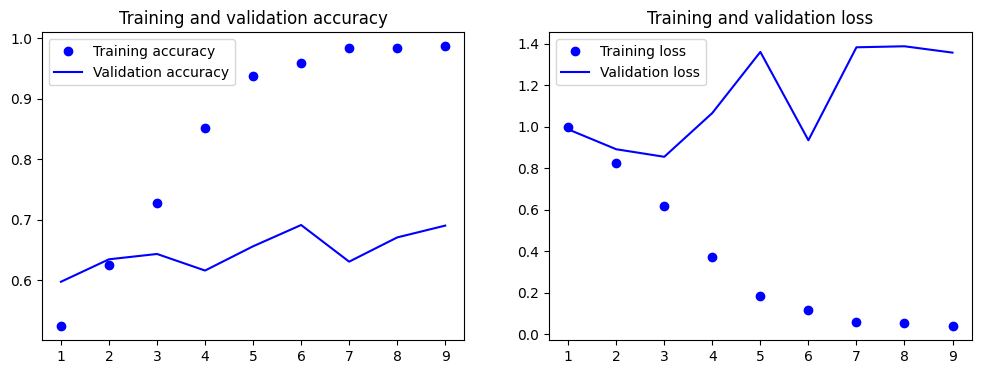

In [18]:
# Optionally, plot the training and validation accuracy and loss
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

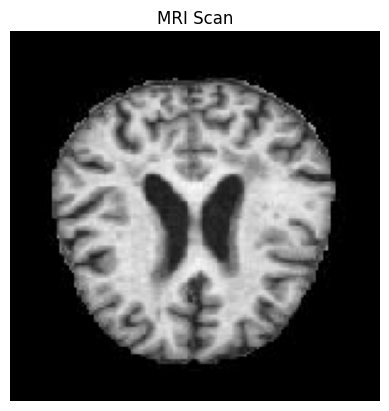

NameError: name 'model' is not defined

In [2]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Define the path to the image
image_path = 'split_dataset/test/MildDemented/29 (4).jpg'

# Load the image
img = image.load_img(image_path, target_size=(150, 150))

# Display the image
plt.imshow(img)
plt.title("MRI Scan")
plt.axis('off')
plt.show()

# Preprocess the image
img_array = image.img_to_array(img)  # Convert the image to a numpy array
img_array = img_array / 255.0  # Rescale the image
img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions to match the model's input shape

# Make a prediction
prediction = model.predict(img_array)

# Define class labels
class_labels = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# Get the predicted class
predicted_class = class_labels[np.argmax(prediction[0])]

print(f'The model predicts: {predicted_class} ({prediction[0][np.argmax(prediction[0])]:.4f})')

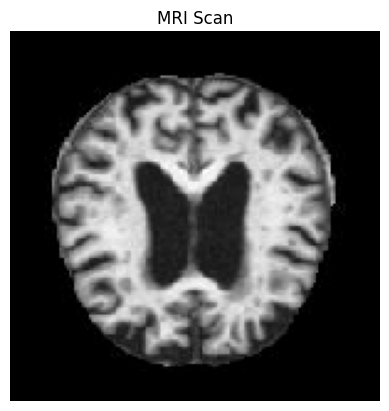

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
The model predicts: VeryMildDemented (0.5796)


In [12]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load the saved model
model = tf.keras.models.load_model('alzheimers_detector_model_with_originalDS_cnn.h5')

# Define the path to the image
image_path = '/Users/arnabsahoo/Downloads/FinalPriject/Alzheimer_s Dataset/test/VeryMildDemented/26 (53).jpg'

# Load the image
img = image.load_img(image_path, target_size=(150, 150))

# Display the image
plt.imshow(img)
plt.title("MRI Scan")
plt.axis('off')
plt.show()

# Preprocess the image
img_array = image.img_to_array(img)  # Convert the image to a numpy array
img_array = img_array / 255.0  # Rescale the image
img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions to match the model's input shape

# Make a prediction
prediction = model.predict(img_array)

# Define class labels
class_labels = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# Get the predicted class
predicted_class = class_labels[np.argmax(prediction[0])]

print(f'The model predicts: {predicted_class} ({prediction[0][np.argmax(prediction[0])]:.4f})')

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Define the categories
categories = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# Load the model
model = tf.keras.models.load_model('alzheimers_detector_model_with_originalDS_cnn.h5')

# Define the test data directory
test_dir = 'split_dataset/test'

# Preprocess the data
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),  # Match this to the input size used during training
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Predict on the test data
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Evaluate the model manually
true_classes = test_generator.classes
accuracy_per_batch = []
loss_per_batch = []

for i, (images, labels) in enumerate(test_generator):
    if i >= len(test_generator):  # Stop when all batches completed
        break
    batch_loss, batch_accuracy = model.evaluate(images, labels, verbose=0)
    accuracy_per_batch.append(batch_accuracy)
    loss_per_batch.append(batch_loss)

print(f'Test Accuracy: {np.mean(accuracy_per_batch) * 100:.2f}%')

# print the categories corresponding to the predictions
# predicted_category_names = [categories[i] for i in predicted_classes]
# print(predicted_category_names)

Found 1281 images belonging to 4 classes.
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Test Accuracy: 91.46%


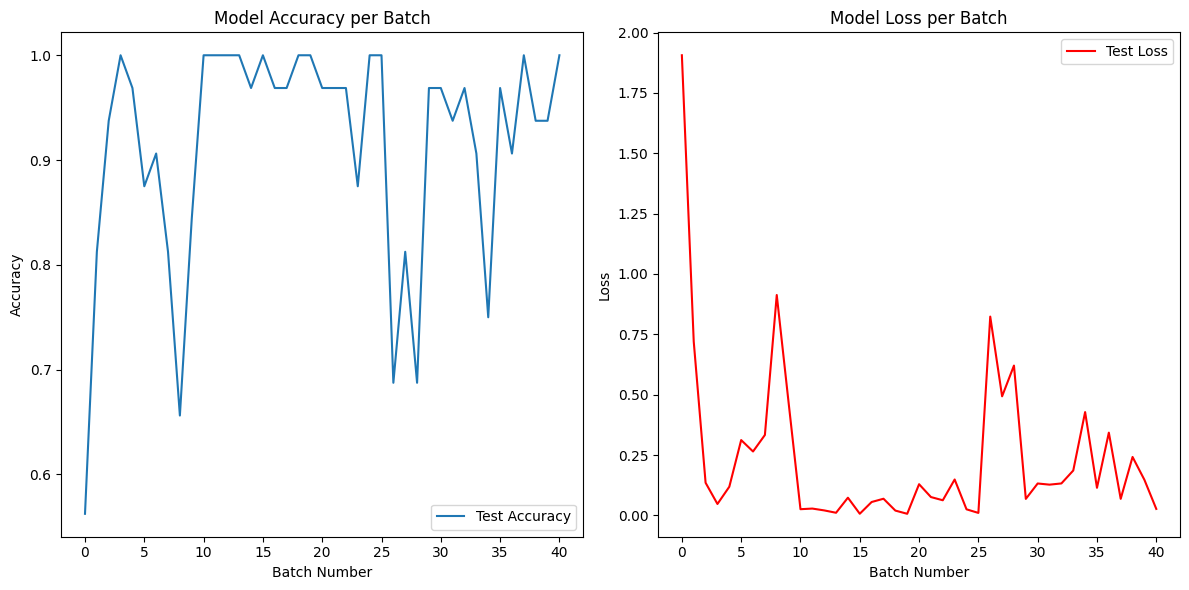

In [15]:
import matplotlib.pyplot as plt

# Plotting accuracy and loss for each batch
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(accuracy_per_batch, label='Test Accuracy')
plt.title('Model Accuracy per Batch')
plt.xlabel('Batch Number')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(loss_per_batch, label='Test Loss', color='red')
plt.title('Model Loss per Batch')
plt.xlabel('Batch Number')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()